## <font color='#1D76BA'>MSC_DA_CA1<font color='#00A859'>
#### <font color='#'>**Programming for DA
#### <font color='#1ABC9C'>**Lecturer(s): Sam Weiss**
<font color='#E74C3C'>**Students name / ID** // Rosilene Francisca da Silva - 2021090
    

#### In this initial step, I will deal with Python Tool and Library Implementation to accomplish basic dataset exploration. 

Since I already have Anaconda installed, Pandas and other well-known packages are installed automatically. You can use the help command to see the list of modules if you're unsure if the package is installed in the programming environment.

In [20]:
#help('modules')

Pandas is one of the widely used Python language packages. It provides powerful tools for manipulating and analysing data in a straightforward and effective manner, while also offering high performance to the scripts.
It is widely used in conjunction with the Numpy package, which focuses on mathematical and statistical operations, which I will also import.

Importing the package into our environment, with the import command:

In [2]:
# Importing the required libraries:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore') #never print matching warnings

There are various ways in Pandas to read data in various formats (like.xlsx,.json, and.csv). These methods often begin with the word `read_` and then the file extension. The dataset utilised in this instance is in the CSV format.

In [3]:
# Importing the Dataset 
datapop_df = pd.read_csv("irelandpopulation.csv")

#### Let's begin by using the head method to see the first five rows of our dataset.

In [4]:
datapop_df.head()

,Statistic Label,CensusYear,Detailed Marital Status,County and City,Sex,Age Group,UNIT,VALUE
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
1,Population,2011,All marital status,State,Both sexes,Under 25 years,Number,1559840
2,Population,2011,All marital status,State,Both sexes,25 - 29 years,Number,361122
3,Population,2011,All marital status,State,Both sexes,30 - 34 years,Number,393945
4,Population,2011,All marital status,State,Both sexes,35 - 39 years,Number,364261


#### Let's now use the `type()` method to verify the class type of the columns.

In [40]:
# Data Types
datapop_df.dtypes

Statistic Label            object
CensusYear                  int64
Detailed Marital Status    object
County and City            object
Sex                        object
Age Group                  object
UNIT                       object
VALUE                       int64
dtype: object

As we can see the dataset has the types as int `integer` and str `string - text`

#### Clearly, the string data present in the dataframe is structured as an object, let's convert it back to string format for further processing.

In [41]:
string_col = datapop_df.select_dtypes(include="object").columns
datapop_df[string_col]=datapop_df[string_col].astype("string")
datapop_df.dtypes

Statistic Label            string
CensusYear                  int64
Detailed Marital Status    string
County and City            string
Sex                        string
Age Group                  string
UNIT                       string
VALUE                       int64
dtype: object

#### Renaming some columns with the 'rename' methods because it's more appropriate.

Rename the dataframe's rows or columns using the `rename()` function. The columns will be renamed based on the data given in the keys if 'columns =' is indicated in the brackets; we must specify the new and current names. We will follow the same procedure, indicating "index=," to update the line names. The old dataframe will not change; only a new dataframe with the new names will be created by simply stating these parameters.
I specify the `inplace = True` parameter in order to modify the original dataframe.
##### `True` is a bool in data types. Boolean data types are used to express truth values, which are commonly denoted as 'True' or 'False'. 

In [10]:
datapop_df.rename(columns={'Detailed Marital Status': 'MaritalStatus', 'County and City': 'Area', 
                           'Sex': 'Gender','Age Group': 'AgeGroup', 'VALUE': 'UnitValue' }, inplace = True)
datapop_df.head(2)

,Statistic Label,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UNIT,UnitValue
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
1,Population,2011,All marital status,State,Both sexes,Under 25 years,Number,1559840


#### Data Dictionary 

Let's  to convert the variable gender into a binary field, that is, replace “Male” by the value 1, Female by the value 2 and Both sexes by the value 3. The 'Gender' column in the DataFrame datapop_df can be changed in-place without generating a new DataFrame by using the `inplace=True` option in the replace function. 

In [11]:
dict_Gender = {'Male':1, 'Female': 2, 'Both sexes': 3}
datapop_df['Gender'] = datapop_df['Gender'] = datapop_df['Gender'].map(dict_Gender)

datapop_df['Gender'].replace(dict_Gender, inplace=True)
datapop_df.head(2)

,Statistic Label,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UNIT,UnitValue
0,Population,2011,All marital status,State,3,All ages,Number,4588252
1,Population,2011,All marital status,State,3,Under 25 years,Number,1559840


In [12]:
print(datapop_df.Gender.unique())

[3 1 2]


Using this code, I tried to convert the values in the DataFrame's "Gender" column to numerical values derived from the dictionary dict_Gender. The overall objective is to demonstrate one method of using data dictionary and to replace the string values with their corresponding numerical equivalent.

Set the index in the strings' MaritalStatus column.

In [51]:
datapop_df.set_index('MaritalStatus')
print(datapop_df)

      Statistic Label  CensusYear       MaritalStatus      Area      Gender  \
0          Population        2011  All marital status     State  Both sexes   
1          Population        2011  All marital status     State  Both sexes   
2          Population        2011  All marital status     State  Both sexes   
3          Population        2011  All marital status     State  Both sexes   
4          Population        2011  All marital status     State  Both sexes   
...               ...         ...                 ...       ...         ...   
33475      Population        2022             Widowed  Monaghan      Female   
33476      Population        2022             Widowed  Monaghan      Female   
33477      Population        2022             Widowed  Monaghan      Female   
33478      Population        2022             Widowed  Monaghan      Female   
33479      Population        2022             Widowed  Monaghan      Female   

                AgeGroup    UNIT  UnitValue  
0    

As we can see, I set the 'MaritalStatus' column the DataFrame's index. I did not use the inplace=True parameter because I dont want to modify the DataFrame in place. 
It can make certain sorts of analysis or data manipulation easier, such as grouping or querying data depending on marital status.

Using the sort_values method, we can arrange area values in ascending order based on the 'UnitValue' column.

In [54]:
#Display the Area by population
value_area = datapop_df.groupby('Area')[['UnitValue']].sum() 
print(value_area.sort_values(by='UnitValue', ascending=True))

                           UnitValue
Area                                
Leitrim                       792328
Longford                     1012992
Carlow                       1388096
Monaghan                     1497256
Roscommon                    1590944
Sligo                        1609008
Cavan                        1848504
Offaly                       1902384
Galway City                  1908888
Laois                        2057064
Westmeath                    2169240
Kilkenny                     2390488
Waterford City and County    2858672
Clare                        2911608
Louth                        3131872
Mayo                         3192920
Wicklow                      3479328
Kerry                        3597336
Wexford                      3671688
Tipperary                    3889616
Donegal                      3899304
Galway County                4382696
Limerick City and County     4769952
Meath                        4800040
Dún Laoghaire-Rathdown       5265112
K

### try-except: 
The try statement defines exception handlers and/or cleanup code for a collection of statements.

I am going to write an example that uses a try-except block to manage any potential exceptions that may arise during data processing.
If the format remains consistent, this changed code will successfully process the dataset provided. The script will divide the data into rows and columns, then process each row, generating a dictionary with the keys and values 'Area' and 'UnitValue'. During data processing, the try-except block will handle any exceptions and output an error message explaining the nature of the exception.

In [8]:
datapop_df = """
Area      UnitValue
Leitrim   792328
Longford  1012992
Carlow    1388096
Monaghan  1497256
Roscommon 1590944
Sligo     1609008
"""

In [9]:
rows = datapop_df.strip().split('\n') # Split the data into rows and columns
columns = rows[0].split()
processed_data = [] # Set up lists for data processing.
for row in rows[1:]: # Handle exceptions and process the data
    try:
        values = row.split()
        processed_data.append(dict(zip(columns, values)))
    except Exception as e:
        print(f"An error occurred: {e}")
for item in processed_data: # Show the processed data
    print(item)

{'Area': 'Leitrim', 'UnitValue': '792328'}
{'Area': 'Longford', 'UnitValue': '1012992'}
{'Area': 'Carlow', 'UnitValue': '1388096'}
{'Area': 'Monaghan', 'UnitValue': '1497256'}
{'Area': 'Roscommon', 'UnitValue': '1590944'}
{'Area': 'Sligo', 'UnitValue': '1609008'}


According to the result, the code correctly processed the data and printed each item in the list of processed data in this case. Each item is a dictionary containing information on the area and its unit value.

Now let's use try and excep with marital status and census year:

In [12]:
try:
    marital_status = input("Enter the Marital Status: ")
    census_year = int(input("Enter the Census Year: "))
    print(f"Marital Status: {marital_status}, Census Year: {census_year}")
except ValueError as e:
    print(f"ValueError: {e}. Please enter a valid Census Year.")
except Exception as e:
    print(f"An error occurred: {e}. Please try again.")

Enter the Marital Status: Sinlge
Enter the Census Year: 2022
Marital Status: Sinlge, Census Year: 2022


The user is prompted by the programme to enter their marital status and the year of the census. The variables marital_status and census_year contain the entered values. The values for the census year and marital status are displayed in the output.
A ValueError will be triggered and handled by the first unless block, which will output an error message, if the value entered for the census year cannot be converted to an integer.
The second unless block will catch any more unexpected errors that arise during the process and print the relevant error message.
I entered "Single" for the marital status and "2016" for the census year in the result that was provided. These values were successfully printed as output by the programme.

##### Now, let's see a result as a `ValueError`.

In [13]:
try:
    marital_status = input("Enter the Marital Status: ")
    census_year = int(input("Enter the Census Year: "))
    print(f"Marital Status: {marital_status}, Census Year: {census_year}")
except ValueError as e:
    print(f"ValueError: {e}. Please enter a valid Census Year.")
except Exception as e:
    print(f"An error occurred: {e}. Please try again.")

Enter the Marital Status: Single
Enter the Census Year: 22.3
ValueError: invalid literal for int() with base 10: '22.3'. Please enter a valid Census Year.


When the programme hits the ValueError, the output displays the relevant error message.

### For Loop 
Ref https://www.w3schools.com/python/python_for_loops.asp

To iterate over the components of a sequence (such as a string, tuple, or list) or other iterable object, use the for statement.

Using a string to Loop
Strings are also iterable objects because they include a sequence of characters:

In [10]:
#Using a loop with marital statuses
marital_statuses = ['Married', 'Divorced', 'Single', 'Remarried', 'Widowed', 'Registered Same Sex']
for status in marital_statuses: 
    print(status)

Married
Divorced
Single
Remarried
Widowed
Registered Same Sex


##### For loop and a conditional statement.

Now, let's see the keyword `continue` only exits the current for loop iteration. When x equals 4, print(x) will not be executed, and hence 4 will not be printed.

In [14]:
x = 0
for x in range(5):
    if x == 4:
        continue
    print(x)

0
1
2
3


We have a list of marital statuses in this example. Every time an element in the list is iterated over, the for loop prints the marital status. each married status in the list's output.

In [11]:
gender = ['Male', 'Female', 'Both sexes']
for x in gender:
    print(x)
    if x == 'Female':
        break

Male
Female


We can break the loop before it loops over all of the objects by using the break statement,as seen in the example.


### Nested Loops: 
When a loop is "inside" another loop, in one or more instances. Every time the outer loop executes once, the inner loop continues until it is finished.
##### Ref: Python for Everybody - page 115

In [12]:
maritalstatus = ['Divorced','Single','Married',]
censusyear = ['2011', '2016', '2022',]
for x in maritalstatus:
    for y in censusyear:
        print(x, y)

Divorced 2011
Divorced 2016
Divorced 2022
Single 2011
Single 2016
Single 2022
Married 2011
Married 2016
Married 2022


The output of this line aggregates the current values of x and y to produce every possible set of items from both lists.
In the result , every element from the `censusyear` list is coupled with every item from the `maritalstatus` list, providing every conceivable combination of entries from both lists.

### While Loop
As long as an expression is true, the while statement is used to execute an expression repeatedly.

In [13]:
censusyear = 2022
while censusyear < 2026:
    print(censusyear)
    censusyear += 8
    if censusyear == 2028:
        print('censusyear is 2022')
        break
else:
    print('End while')

2022
End while


In this example, the current value of censusyear is reported during each loop iteration, and then 8 is added to it. The code, however, includes a conditional statement that checks to see if the censusyear is equal to 2028. If it is, it writes 'censusyear is 2022' and exits the loop. the condition censusyear == 2028, however, is never met because the loop ends when censusyear becomes 2030, which is greater than 2026. As a result, the 'else' block is run, and the statement 'End while' was printed.

#### See the example below to find the number that appears the fewest amount of times in a list:

In [14]:
#Creating a list of random numbers

my_list = [8, 4, 2, 4, 8, 3, 2, 4,3,1,4,1,2,1]
counter = 0
counter_list = [my_list.count(x) for x in my_list]
smallest_number = None 

while counter < len(my_list):
    if counter_list[counter] == min(counter_list):
        smallest_number = my_list[counter]
        counter += 1
    else:
        counter += 1
print('The number that appears the fewest times is:', smallest_number)

The number that appears the fewest times is: 3


In this scenario, the while loop through each member in my_list. It compares the count of each element with the minimal count. If the count matches the minimum count, the relevant element is assigned to smallest_number. Finally, it outputs the smallest number that appears in the list my_list the fewest times, which is 3 in our case.

### Function / Function calls


Lets creating a fuction and perfom a simple utility that allows you to add or multiply two numbers, with the possibility of including extra numbers for multiplication and arguments. It will also handles errors for invalid operations.

In [310]:
#function named perform_operation
def perform_operation():
     print("This is a perform_operation!")
perform_operation()

This is a perform_operation!


In [309]:
def perform_operation(operation, num2, num8, *args):
    if operation == 'sum' or operation == 'add':
        total = num2 + num8
    elif operation == 'multiply':
        total = num2 * num8
        if args:
            for num in args:
                total *= num
    else:
        raise ValueError("Invalid operation. Please use 'sum', 'add', or 'multiply'.")
    return total

In [307]:
add_result = perform_operation('add', 4,2)
print(add_result)

6


In [308]:
mult_result = perform_operation('multiply', 6,24)
print(mult_result)

144


When the `perform_operation` function was called an addition and multiplication are carried out via the first and second calls, respectively.

In [261]:
#Creating a function
def my_function():
    print('My first CA of PDA')

In [262]:
#Calling a function
def my_function():
    print('My first CA of PDA')
my_function()

My first CA of PDA


Use the function name in parenthesis to call the function.

### Programming Paradigm
A paradigm is a style or approach to problem solving and developing code in programming. There are several popular programming paradigms, each with their own set of characteristics and beliefs.

The four most frequent paradigms are:
Imperative / Procedural / Functional / Declarative  and Object-oriented

Furthermore, I will give Python code examples that cover real-world scenarios in each Paradigm.

##### Imperative / Procedural 
Let's see an example where a programme that determines the average of a list of numbers.

In [17]:
def calculate_sum(list):
    sum_result = 0
    for number in list:
        sum_result += number
    return sum_result
numbers = [4, 2, 6, 1, 2]
sum_result = calculate_sum(numbers)
print('The sum_result of the numbers is:', sum_result)

The sum_result of the numbers is: 15


In this example, the calculate sum function iterates through the list of integers using a for loop, adding up each number's sum in the sum variable. The function returns the result, which is then displayed on the result.

##### Functional

In [18]:
numbers = [2, 4, 1, 2, 5]
sum_result = sum(numbers)
print("The sum of the numbers is:", sum_result)

The sum of the numbers is: 14


In this example, I applied Python's sum function, which takes a list of numbers and returns their sum. We don't need to build a custom function or use an explicit loop because the sum function already does this reasoning functionally.

#### Declarative
Consider the following scenario: we want to develop a button that shows a message when clicked.

In [40]:
#import tkinter as tk

In [41]:
def display_message():
    print('The button was clicked!')
window = tk.Tk()
button = tk.Button(window, text='Click here')
button.bind('<Button-1>', lambda event: display_message())
button.pack()
window.mainloop()

In this example above, we create a window with a button using the Tkinter package. We define the display_message function, which is called when the button is pressed. Then, using the bind technique, we correlate the button click event (Button-1>) with the display_message function. When the button is pressed, the display_message function is called, which outputs a message. 
See the image below:
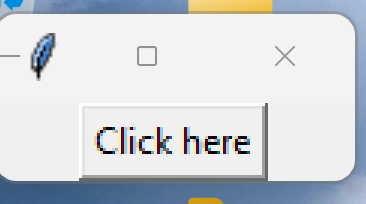

##### Object-oriented
Here's an example of how we might model a simple calculator:

In [19]:
class Calculator:
    def __init__(self):
        self.value = 0
    def add(self, num):
        self.value += num
    def subtract(self, num):
        self.value -= num
    def get_result(self):
        return self.value

calculator = Calculator()
calculator.add(6)
calculator.subtract(2)
result = calculator.get_result()
print("The result of the calculator is:", result)

The result of the calculator is: 4


In this scenario, we constructed a calculator class with a value attribute set to zero. The class includes add and subtract methods for modifying the calculator value. We also have theobtain_resultado method, which returns the calculator's current value.Calculator is an instance of the Calculator class that we construct. Following that, we call the add and remove methods, passing the numbers 5 and 3, respectively. Finally, we use the get_result method to retrieve the current calculator result and display it on the result.

It is critical to understand these paradigms in order to select the best method for each project while keeping readability, maintainability, and efficiency in mind. We can become more adaptable and competent programmers at tackling complicated problems by broadening our understanding of diverse programming paradigms.

#### Combining Data in Pandas

In [8]:
import pandas as pd

In [9]:
# Importing the Dataset 1 
popdata_2022 = pd.read_csv("2022population.csv")
popdata_2022.head()

,Statistic Label,Census Year,Administrative Counties 2019,Marital Status,Sex,UNIT,VALUE
0,Population,2022,Carlow County Council,Single,Males,Number,17173
1,Population,2022,Carlow County Council,Single,Females,Number,15769
2,Population,2022,Carlow County Council,Single,Both Sexes,Number,32942
3,Population,2022,Carlow County Council,Married,Males,Number,11488
4,Population,2022,Carlow County Council,Married,Females,Number,11492


In [10]:
# Importing the Dataset 2
popcar_2022 = pd.read_csv("householdswithcars.csv")
popcar_2022.head()

,Statistic Label,Census Year,Administrative Counties,Number of Cars,UNIT,VALUE
0,Number of households with cars,2022,Carlow County Council,No motor car,Number,2510
1,Number of households with cars,2022,Carlow County Council,1 motor car,Number,8235
2,Number of households with cars,2022,Carlow County Council,2 motor cars,Number,7408
3,Number of households with cars,2022,Carlow County Council,3 motor cars,Number,1651
4,Number of households with cars,2022,Carlow County Council,4 or more motor cars,Number,683


In [11]:
 # Display the dimensions of the Dataset 1
popdata_2022.shape 

(576, 7)

In [12]:
# Display the dimensions of the Dataset 2
popcar_2022.shape 

(160, 6)

Since the observations in the two datasets are identical, I will rename the 'Administrative Counties 2019' column in the first dataset. Combining datasets will be simpler as a result.

In [243]:
popdata_2022.rename(columns={'Administrative Counties 2019': 'Administrative Counties', }, inplace = True)
popdata_2022.head(2)

,Statistic Label,Census Year,Administrative Counties,Marital Status,Sex,UNIT,VALUE
0,Population,2022,Carlow County Council,Single,Males,Number,17173
1,Population,2022,Carlow County Council,Single,Females,Number,15769


In [244]:
#Checkin null values in the datasets
popdata2022null = popdata_2022.isna().sum().sum()
popcar2022null = popcar_2022.isna().sum().sum()
print ('Null values in popdata_2022: {}'.format(popdata2022null))
print ('Null values in popcar_2022: {}'.format(popcar2022null))

Null values in popdata_2022: 0
Null values in popcar_2022: 0


The datasest does not contain any null values. As a result, there is no need to clean the datasets.

#Creating a mapp dictionary for renaming values in data_2016 to match data_2022
mapping_dict = {'Carlow': 'Carlow County Council','Limerick City and County': 
}

To merge the two datasetes I will apply the method `how='inner'` the type of merge is specified by this option. An inner join preserves only the rows that are shared by the two DataFrames. I also apply the `on=`for the columns 'Census Year', 'Administrative Counties'amd 'UNIT. I decided to this parameter to indicates the columns that will be used for merging. The function will merge DataFrames with the same values in the specified columns.

In [246]:
new_data = pd.merge(popdata_2022, popcar_2022, how='inner', on=['Census Year', 'Administrative Counties', 'UNIT'])
new_data.head()

,Statistic Label_x,Census Year,Administrative Counties,Marital Status,Sex,UNIT,VALUE_x,Statistic Label_y,Number of Cars,VALUE_y
0,Population,2022,Carlow County Council,Single,Males,Number,17173,Number of households with cars,No motor car,2510
1,Population,2022,Carlow County Council,Single,Males,Number,17173,Number of households with cars,1 motor car,8235
2,Population,2022,Carlow County Council,Single,Males,Number,17173,Number of households with cars,2 motor cars,7408
3,Population,2022,Carlow County Council,Single,Males,Number,17173,Number of households with cars,3 motor cars,1651
4,Population,2022,Carlow County Council,Single,Males,Number,17173,Number of households with cars,4 or more motor cars,683


In [247]:
new_data.shape

(2880, 10)

The combined dataframe's shape after the datasets are merged is (2880, 10). This shows that as a result of the merging procedure, there are now more rows and columns than before. It happened because the merging process resulted in a combination of rows that matched the merging criteria.

In [248]:
print(new_data.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2880 entries, 0 to 2879
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Statistic Label_x        2880 non-null   object
 1   Census Year              2880 non-null   int64 
 2   Administrative Counties  2880 non-null   object
 3   Marital Status           2880 non-null   object
 4   Sex                      2880 non-null   object
 5   UNIT                     2880 non-null   object
 6   VALUE_x                  2880 non-null   int64 
 7   Statistic Label_y        2880 non-null   object
 8   Number of Cars           2880 non-null   object
 9   VALUE_y                  2880 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 247.5+ KB
None


#### DataFrame.transpose
Let's apply the transpose method in the dataset 'irelandpopulation'.
The original rows will become columns in the transposed data after applied the methods, and vice versa. 
To indicate that a new duplicate of the data shouldn't be created, I applied the `copy=False` argument.

In [7]:
datapop_df.transpose(copy=False)

,0,1,2,3,4,5,6,7,8,9,...,33470,33471,33472,33473,33474,33475,33476,33477,33478,33479
Statistic Label,Population,Population,Population,Population,Population,Population,Population,Population,Population,Population,...,Population,Population,Population,Population,Population,Population,Population,Population,Population,Population
CensusYear,2011,2011,2011,2011,2011,2011,2011,2011,2011,2011,...,2022,2022,2022,2022,2022,2022,2022,2022,2022,2022
Detailed Marital Status,All marital status,All marital status,All marital status,All marital status,All marital status,All marital status,All marital status,All marital status,All marital status,All marital status,...,Widowed,Widowed,Widowed,Widowed,Widowed,Widowed,Widowed,Widowed,Widowed,Widowed
County and City,State,State,State,State,State,State,State,State,State,State,...,Monaghan,Monaghan,Monaghan,Monaghan,Monaghan,Monaghan,Monaghan,Monaghan,Monaghan,Monaghan
Sex,Both sexes,Both sexes,Both sexes,Both sexes,Both sexes,Both sexes,Both sexes,Both sexes,Both sexes,Both sexes,...,Female,Female,Female,Female,Female,Female,Female,Female,Female,Female
Age Group,All ages,Under 25 years,25 - 29 years,30 - 34 years,35 - 39 years,40 - 44 years,45 - 49 years,50 - 54 years,55 - 59 years,60 - 64 years,...,40 - 44 years,45 - 49 years,50 - 54 years,55 - 59 years,60 - 64 years,65 - 69 years,70 - 74 years,75 - 79 years,80 - 84 years,85 years and over
UNIT,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,...,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number
VALUE,4588252,1559840,361122,393945,364261,330812,305185,274386,244522,218786,...,18,44,53,110,138,201,332,359,363,522


Although I personally prefer this datasets without transposition indexes and columns, but this function can be especially helpful in bending data in preparation for specific kinds of analysis and visualisation.